# Overnight Gaps Strategy Demonstration

This notebook demonstrates the Overnight Gaps / Midnight Returns Strategy as described in `docs/overnight_gaps_strategy.md`.

The strategy analyzes overnight gaps in stock prices, where a gap occurs when the opening price differs significantly from the previous day's close. It measures whether these gaps get filled during the trading day and captures the same-day price movement.

## Step 1: Understanding the Strategy

### What the Strategy Measures:
- **Gap Calculation**: Compares each session's open to the prior close to identify gap-up or gap-down events.
- **Intraday Fill**: Determines if the price revisits the prior close during the same trading day.
- **Same-day Drift**: Captures the movement from open to close on the gap day.

### Key Concepts:
- **Gap %**: (today_open - prev_close) / prev_close * 100
- **Direction**: 'up' if gap > 0, 'down' if gap < 0
- **Filled**: For up gaps, filled if day's low ≤ prior close. For down gaps, filled if day's high ≥ prior close.
- **Same-day Close Return**: (close - open) / open * 100

## Step 2: Setup and Data Acquisition

We'll use Yahoo Finance to fetch daily stock data. The strategy requires daily candles with open, high, low, close prices.

Parameters:
- Symbol: AAPL (Apple Inc.)
- Lookback: 120 days
- Minimum gap threshold: 1%

In [1]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Parameters
symbol = 'TSLA'
lookback_days = 400
min_gap_pct = 1.0

print(f"Analyzing {symbol} for the last {lookback_days} days with minimum gap of {min_gap_pct}%")

Analyzing TSLA for the last 400 days with minimum gap of 1.0%


In [3]:
# Fetch data from Yahoo Finance
data = yf.download(symbol, period=f'{lookback_days}d', interval='1d', multi_level_index=False)
data = data.dropna()  # Remove any missing data

print(f"Fetched {len(data)} days of data")
print(data.head())

C:\Users\User\AppData\Local\Temp\ipykernel_46316\3272169898.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, period=f'{lookback_days}d', interval='1d', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed

Fetched 400 days of data
                 Close        High         Low        Open     Volume
Date                                                                 
2024-06-13  182.470001  191.080002  181.229996  188.389999  118984100
2024-06-14  178.009995  186.000000  176.919998  185.800003   82038200
2024-06-17  187.440002  188.809998  177.000000  177.919998  109786100
2024-06-18  184.860001  187.199997  182.369995  186.559998   68982300
2024-06-20  181.570007  185.210007  179.660004  184.679993   55893100


In [4]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

## Step 3: Computing Gaps

Now we'll calculate the overnight gaps for each day. A gap occurs when today's open is different from yesterday's close.

Formula: Gap % = (today_open - prev_close) / prev_close * 100

In [5]:
# Calculate gaps
data['prev_close'] = data['Close'].shift(1)
data['gap_pct'] = ((data['Open'] - data['prev_close']) / data['prev_close']) * 100

# Filter out small gaps
gaps = data[abs(data['gap_pct']) >= min_gap_pct].copy()

# Determine direction
gaps['direction'] = np.where(gaps['gap_pct'] > 0, 'up', 'down')

print(f"Found {len(gaps)} significant gaps (>{min_gap_pct}%)")
print(f"Up gaps: {len(gaps[gaps['direction'] == 'up'])}")
print(f"Down gaps: {len(gaps[gaps['direction'] == 'down'])}")
print(gaps[['gap_pct', 'direction']].head())

Found 206 significant gaps (>1.0%)
Up gaps: 127
Down gaps: 79
             gap_pct direction
Date                          
2024-06-14  1.824959        up
2024-06-24  1.070983        up
2024-06-28  1.078921        up
2024-07-01  1.586820        up
2024-07-02  4.302868        up


## Step 4: Checking Intraday Fills

For each gap, we check if it gets filled during the trading day:
- **Up gap filled**: If the day's low price falls at or below the previous close
- **Down gap filled**: If the day's high price rises at or above the previous close

In [6]:
# Check if gaps are filled intraday
gaps['filled'] = False

# Up gaps: filled if low <= prev_close
up_gaps = gaps['direction'] == 'up'
gaps.loc[up_gaps, 'filled'] = gaps.loc[up_gaps, 'Low'] <= gaps.loc[up_gaps, 'prev_close']

# Down gaps: filled if high >= prev_close
down_gaps = gaps['direction'] == 'down'
gaps.loc[down_gaps, 'filled'] = gaps.loc[down_gaps, 'High'] >= gaps.loc[down_gaps, 'prev_close']

# Calculate same-day close return
gaps['same_day_close_ret'] = ((gaps['Close'] - gaps['Open']) / gaps['Open']) * 100

print("Fill statistics:")
print(f"Overall fill rate: {gaps['filled'].mean() * 100:.1f}%")
print(f"Up gap fill rate: {gaps[up_gaps]['filled'].mean() * 100:.1f}%")
print(f"Down gap fill rate: {gaps[down_gaps]['filled'].mean() * 100:.1f}%")

print("\nSample gap data:")
print(gaps[['gap_pct', 'direction', 'filled', 'same_day_close_ret']].head())

Fill statistics:
Overall fill rate: 41.7%
Up gap fill rate: 44.9%
Down gap fill rate: 36.7%

Sample gap data:
             gap_pct direction  filled  same_day_close_ret
Date                                                      
2024-06-14  1.824959        up    True           -4.192685
2024-06-24  1.070983        up    True           -1.292101
2024-06-28  1.078921        up    True           -0.836882
2024-07-01  1.586820        up   False            4.397570
2024-07-02  4.302868        up   False            5.651238


## Step 5: Visualization

Let's create visualizations to better understand the gaps and their fills.

We'll create:
1. A time series plot showing gap sizes over time
2. A histogram of gap sizes
3. A scatter plot of gap size vs same-day return

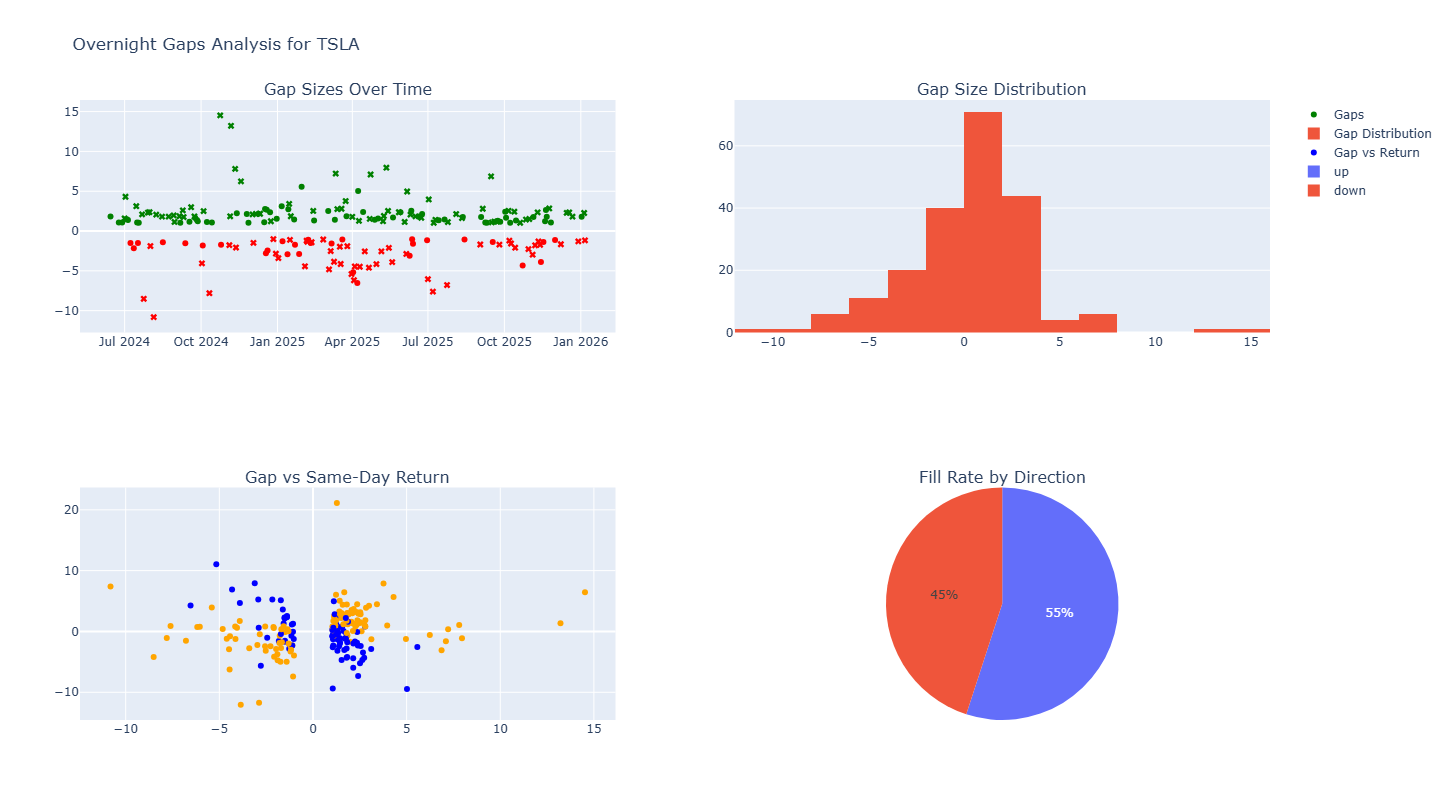

Plot saved to graphs/TSLA_gaps_analysis.html


In [7]:
# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Gap Sizes Over Time', 'Gap Size Distribution', 
                    'Gap vs Same-Day Return', 'Fill Rate by Direction'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"type": "domain"}]]
)

# 1. Gap sizes over time
fig.add_trace(
    go.Scatter(x=gaps.index, y=gaps['gap_pct'], mode='markers',
               marker=dict(color=gaps['direction'].map({'up': 'green', 'down': 'red'}),
                          symbol=gaps['filled'].map({True: 'circle', False: 'x'})),
               name='Gaps'),
    row=1, col=1
)

# 2. Gap size distribution
fig.add_trace(
    go.Histogram(x=gaps['gap_pct'], nbinsx=20, name='Gap Distribution'),
    row=1, col=2
)

# 3. Gap vs same-day return
fig.add_trace(
    go.Scatter(x=gaps['gap_pct'], y=gaps['same_day_close_ret'], mode='markers',
               marker=dict(color=gaps['filled'].map({True: 'blue', False: 'orange'})),
               name='Gap vs Return'),
    row=2, col=1
)

# 4. Fill rate by direction
fill_rates = gaps.groupby('direction')['filled'].mean() * 100
fig.add_trace(
    go.Pie(labels=fill_rates.index, values=fill_rates.values, name='Fill Rates'),
    row=2, col=2
)

fig.update_layout(height=800, title_text=f"Overnight Gaps Analysis for {symbol}")
fig.show()

# Save the plot
graphs_dir = 'graphs'
if not os.path.exists(graphs_dir):
    os.makedirs(graphs_dir)

fig.write_html(os.path.join(graphs_dir, f'{symbol}_gaps_analysis.html'))
print(f"Plot saved to {graphs_dir}/{symbol}_gaps_analysis.html")

## Step 6: Summary Statistics

Let's calculate and display key statistics about the gaps.

In [8]:
# Summary statistics
summary = {
    'Total Gaps': len(gaps),
    'Up Gaps': len(gaps[gaps['direction'] == 'up']),
    'Down Gaps': len(gaps[gaps['direction'] == 'down']),
    'Overall Fill Rate': f"{gaps['filled'].mean() * 100:.1f}%",
    'Up Gap Fill Rate': f"{gaps[up_gaps]['filled'].mean() * 100:.1f}%",
    'Down Gap Fill Rate': f"{gaps[down_gaps]['filled'].mean() * 100:.1f}%",
    'Average Gap Size': f"{gaps['gap_pct'].mean():.2f}%",
    'Average Same-Day Drift': f"{gaps['same_day_close_ret'].mean():.2f}%",
    'Largest Up Gap': f"{gaps[gaps['direction'] == 'up']['gap_pct'].max():.2f}%" if len(gaps[gaps['direction'] == 'up']) > 0 else 'N/A',
    'Largest Down Gap': f"{gaps[gaps['direction'] == 'down']['gap_pct'].min():.2f}%" if len(gaps[gaps['direction'] == 'down']) > 0 else 'N/A'
}

print("Summary Statistics:")
for key, value in summary.items():
    print(f"{key}: {value}")

# Recent gaps
print("\nRecent Gaps:")
recent = gaps.tail(5)[['gap_pct', 'direction', 'filled', 'same_day_close_ret']]
print(recent)

Summary Statistics:
Total Gaps: 206
Up Gaps: 127
Down Gaps: 79
Overall Fill Rate: 41.7%
Up Gap Fill Rate: 44.9%
Down Gap Fill Rate: 36.7%
Average Gap Size: 0.39%
Average Same-Day Drift: 0.11%
Largest Up Gap: 14.52%
Largest Down Gap: -10.81%

Recent Gaps:
             gap_pct direction  filled  same_day_close_ret
Date                                                      
2025-12-22  1.803822        up   False           -0.234750
2025-12-29 -1.302637      down   False           -1.995732
2026-01-02  1.796670        up    True           -4.309738
2026-01-05  2.264474        up   False            0.821452
2026-01-06 -1.171211      down   False           -3.006410


## Step 7: Trading Decision Rationale

Based on the overnight gaps analysis, here are the key principles for making buy/sell/hold decisions:

### Gap Fill Analysis
- **Filled Gaps**: When a gap gets filled intraday, it suggests **mean reversion** is occurring. The price returned to the previous day's close level.
  - **Up Gap Filled**: Price fell back to previous close - potential **SELL** signal (resistance at gap level)
  - **Down Gap Filled**: Price rose back to previous close - potential **BUY** signal (support at gap level)

- **Unfilled Gaps**: When a gap remains unfilled, it suggests **momentum continuation** in the gap direction.
  - **Unfilled Up Gap**: Price stayed above previous close - potential **BUY** signal (momentum up)
  - **Unfilled Down Gap**: Price stayed below previous close - potential **SELL** signal (momentum down)

### Decision Framework
1. **Immediate Reaction (Gap Day)**:
   - If gap fills quickly: Consider fading the gap (trade against the gap direction)
   - If gap persists: Consider following the gap (trade in gap direction)

2. **Next Day Analysis**:
   - **Hold/Buy**: If gap was filled and price closed near the fill level (potential support/resistance)
   - **Sell**: If unfilled gap continued strongly in gap direction
   - **Hold**: If gap behavior is inconclusive or in low volume conditions

3. **Risk Management**:
   - Place stops at the previous day's close level (the gap edge)
   - Consider gap size: Larger gaps (>3-5%) are more significant
   - Monitor volume: High volume gaps are more reliable signals

### Practical Examples
- **Filled Up Gap**: Stock gaps up 3% on earnings, but fills by noon. **Decision: SELL** short-term as resistance forms at gap level.
- **Unfilled Down Gap**: Stock gaps down 2% on news, stays down all day. **Decision: HOLD** or **SELL** more if momentum continues.
- **Small Gaps**: Gaps under 1% are often noise. **Decision: HOLD** and wait for clearer signals.

**Important**: Gap strategies work best in trending markets and should be combined with other technical indicators for confirmation.

## Conclusion

This notebook demonstrated the Overnight Gaps Strategy by:

1. **Fetching historical data** from Yahoo Finance
2. **Calculating overnight gaps** between consecutive trading days
3. **Determining gap direction** (up or down)
4. **Checking intraday fills** based on daily high/low prices
5. **Analyzing same-day price movement** after the gap
6. **Visualizing the results** with interactive Plotly charts
7. **Computing summary statistics** for the analysis period

The strategy helps identify patterns in how gaps behave and whether they tend to be filled during the trading day. This can be useful for understanding market behavior and developing trading strategies around gap events.

Key insights from this analysis:
- Gaps occur when there's significant news or events overnight
- Many gaps get filled during the trading day, suggesting mean-reversion
- The direction and size of the gap can influence same-day price movement
- Visualization helps identify patterns and outliers